# Download Dataset

The `vot-toolkit` package on pypi appears to be broken so use this patch and install it from source instead.

In [1]:
# %pip install git+https://github.com/saeejithnair/toolkit.git
# !vot initialize
!mkdir -p dataset/vot18st
!vot initialize vot2018/shortterm --workspace dataset/vot18st
!ls dataset/vot18st/sequences
!ls dataset/vot18st/sequences/butterfly

Workspace already initialized
ants1        book         fish1        gymnastics3  motocross2   soccer2
ants3        butterfly    fish2        hand         nature       soldier
bag          car1         fish3        handball1    pedestrian1  tiger
ball1        conduction1  flamingo1    handball2    rabbit       traffic
ball2        crabs1       frisbee      helicopter   racing       wiper
basketball   crossing     girl         iceskater1   road         zebrafish1
birds1       dinosaur     glove        iceskater2   shaking
blanket      drone1       godfather    leaves       sheep
bmx          drone_across graduate     list.txt     singer2
bolt1        drone_flip   gymnastics1  matrix       singer3
bolt2        fernando     gymnastics2  motocross1   soccer1
camera_motion.tag illum_change.tag  practical.value
color             motion_change.tag sequence
groundtruth.txt   occlusion.tag     size_change.tag


# Explore Dataset
Next, let's take a look at the VOT18 ST dataset. Most of this is not relevant for your assignment, but it should help give you a better idea of what the sequences look like and how to parse the ground truth data

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def parse_groundtruth(gt_file):
    """Parse the groundtruth.txt file which contains quadrilateral coordinates for each frame."""
    with open(gt_file, 'r') as f:
        lines = f.readlines()

    # Each line contains 8 values: x1,y1,x2,y2,x3,y3,x4,y4 (quadrilateral corners)
    gt_boxes = []
    for line in lines:
        coords = list(map(float, line.strip().split(',')))
        # Reshape to 4x2 array (4 points with x,y coordinates)
        box = np.array(coords).reshape(4, 2)
        gt_boxes.append(box)

    return gt_boxes

def parse_tag_file(tag_file):
    """Parse a tag file which contains binary indicators for each frame."""
    with open(tag_file, 'r') as f:
        lines = f.readlines()

    # Each line contains a 0 or 1 indicating if the tag applies to that frame
    tags = [int(line.strip()) for line in lines]
    return tags

def load_sequence_info(sequence_dir):
    """Load sequence information including images, groundtruth, and tags."""
    # Parse sequence file
    sequence_file = os.path.join(sequence_dir, 'sequence')
    sequence_info = {}
    with open(sequence_file, 'r') as f:
        for line in f:
            if '=' in line:
                key, value = line.strip().split('=', 1)
                sequence_info[key] = value

    # Get image paths
    color_pattern = sequence_info.get('channels.color', 'color/%08d.jpg')
    fps = int(sequence_info.get('fps', 30))

    # Get all image files
    color_dir = os.path.join(sequence_dir, 'color')
    image_files = sorted([os.path.join(color_dir, f) for f in os.listdir(color_dir) if f.endswith('.jpg')])

    # Parse groundtruth
    gt_file = os.path.join(sequence_dir, 'groundtruth.txt')
    gt_boxes = parse_groundtruth(gt_file)

    # Parse tag files
    tag_files = [f for f in os.listdir(sequence_dir) if f.endswith('.tag')]
    tags = {}
    for tag_file in tag_files:
        tag_name = tag_file.split('.')[0]
        tags[tag_name] = parse_tag_file(os.path.join(sequence_dir, tag_file))

    # Parse practical.value file if it exists
    practical_file = os.path.join(sequence_dir, 'practical.value')
    practical_values = None
    if os.path.exists(practical_file):
        with open(practical_file, 'r') as f:
            practical_values = [float(line.strip()) for line in f.readlines()]

    return {
        'sequence_info': sequence_info,
        'image_files': image_files,
        'gt_boxes': gt_boxes,
        'tags': tags,
        'fps': fps,
        'practical_values': practical_values
    }

def draw_box(frame, box, color=(0, 255, 0), thickness=2):
    """Draw a quadrilateral box on the frame."""
    # Convert box to integer points
    points = box.astype(np.int32)
    # Draw the quadrilateral
    cv2.polylines(frame, [points], True, color, thickness)
    return frame

def visualize_sequence(sequence_data, output_video=None, show_frames=False):
    """Visualize the sequence with groundtruth boxes and optionally save to video."""
    image_files = sequence_data['image_files']
    gt_boxes = sequence_data['gt_boxes']
    tags = sequence_data['tags']
    fps = sequence_data['fps']
    practical_values = sequence_data.get('practical_values', None)

    # Create video writer if output_video is specified
    if output_video:
        # Read first frame to get dimensions
        first_frame = cv2.imread(image_files[0])
        height, width = first_frame.shape[:2]

        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        video_writer = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

    # Process each frame
    for i, (img_file, gt_box) in enumerate(zip(image_files, gt_boxes)):
        # Read the frame
        frame = cv2.imread(img_file)

        # Draw groundtruth box
        frame = draw_box(frame, gt_box, color=(0, 255, 0), thickness=2)

        # Add tag information
        y_offset = 30
        for tag_name, tag_values in tags.items():
            if i < len(tag_values) and tag_values[i] == 1:
                cv2.putText(frame, tag_name, (10, y_offset),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                y_offset += 25

        # Add practical value if available
        if practical_values and i < len(practical_values):
            cv2.putText(frame, f"Practical: {practical_values[i]:.2f}", (10, y_offset),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 255), 2)
            y_offset += 25

        # Add frame number
        cv2.putText(frame, f"Frame: {i+1}/{len(image_files)}", (10, y_offset),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

        # Show frame if requested
        if show_frames:
            cv2.imshow('Frame', frame)
            if cv2.waitKey(30) & 0xFF == ord('q'):
                break

        # Write to video if requested
        if output_video:
            video_writer.write(frame)

    # Release resources
    if output_video:
        video_writer.release()

    if show_frames:
        cv2.destroyAllWindows()

def analyze_tag_statistics(sequence_data):
    """Analyze and print statistics about the tags in the sequence."""
    tags = sequence_data['tags']
    total_frames = len(sequence_data['image_files'])

    print(f"Total frames: {total_frames}")
    print("\nTag statistics:")
    for tag_name, tag_values in tags.items():
        count = sum(tag_values)
        percentage = (count / total_frames) * 100
        print(f"  {tag_name}: {count} frames ({percentage:.2f}%)")

def calculate_box_metrics(gt_boxes):
    """Calculate metrics about the bounding boxes over time."""
    areas = []
    aspect_ratios = []
    movements = []

    for i, box in enumerate(gt_boxes):
        # Calculate area using Shoelace formula
        x = box[:, 0]
        y = box[:, 1]
        area = 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
        areas.append(area)

        # Calculate approximate aspect ratio (using min/max coords as a rough estimate)
        width = np.max(x) - np.min(x)
        height = np.max(y) - np.min(y)
        aspect_ratio = width / height if height > 0 else 0
        aspect_ratios.append(aspect_ratio)

        # Calculate movement (center point displacement)
        if i > 0:
            prev_center = np.mean(gt_boxes[i-1], axis=0)
            curr_center = np.mean(box, axis=0)
            movement = np.linalg.norm(curr_center - prev_center)
            movements.append(movement)

    # If no movement data (e.g., only 1 frame), fill with a single zero
    if not movements:
        movements = [0]

    return {
        'areas': areas,
        'aspect_ratios': aspect_ratios,
        'movements': movements
    }

def plot_metrics(sequence_data, metrics, output_dir=None):
    """Plot various metrics about the sequence."""
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Plot box areas over time
    plt.figure(figsize=(12, 6))
    plt.plot(metrics['areas'])
    plt.title('Bounding Box Area Over Time')
    plt.xlabel('Frame')
    plt.ylabel('Area (pixels²)')
    plt.grid(True)
    if output_dir:
        plt.savefig(os.path.join(output_dir, 'box_areas.png'))
        plt.close()
    else:
        plt.show()

    # Plot aspect ratios over time
    plt.figure(figsize=(12, 6))
    plt.plot(metrics['aspect_ratios'])
    plt.title('Bounding Box Aspect Ratio Over Time')
    plt.xlabel('Frame')
    plt.ylabel('Aspect Ratio (width/height)')
    plt.grid(True)
    if output_dir:
        plt.savefig(os.path.join(output_dir, 'aspect_ratios.png'))
        plt.close()
    else:
        plt.show()

    # Plot movements over time
    plt.figure(figsize=(12, 6))
    plt.plot(metrics['movements'])
    plt.title('Object Movement Between Frames')
    plt.xlabel('Frame')
    plt.ylabel('Movement (pixels)')
    plt.grid(True)
    if output_dir:
        plt.savefig(os.path.join(output_dir, 'movements.png'))
        plt.close()
    else:
        plt.show()

    # Plot tag occurrences
    tags = sequence_data['tags']
    if tags:
        plt.figure(figsize=(12, 6))
        for tag_name, tag_values in tags.items():
            if sum(tag_values) > 0:  # Only plot non-empty tags
                plt.plot(tag_values, label=tag_name)
        plt.title('Tag Occurrences Over Time')
        plt.xlabel('Frame')
        plt.ylabel('Tag Present (1) or Absent (0)')
        plt.legend()
        plt.grid(True)
        if output_dir:
            plt.savefig(os.path.join(output_dir, 'tag_occurrences.png'))
            plt.close()
        else:
            plt.show()

    # Plot practical values if available
    practical_values = sequence_data.get('practical_values', None)
    if practical_values:
        plt.figure(figsize=(12, 6))
        plt.plot(practical_values)
        plt.title('Practical Values Over Time')
        plt.xlabel('Frame')
        plt.ylabel('Practical Value')
        plt.grid(True)
        if output_dir:
            plt.savefig(os.path.join(output_dir, 'practical_values.png'))
            plt.close()
        else:
            plt.show()

def visualize_trajectory(sequence_data, output_file=None):
    """Visualize the trajectory of the object across all frames."""
    gt_boxes = sequence_data['gt_boxes']

    # Get the first frame to use as background
    first_frame = cv2.imread(sequence_data['image_files'][0])
    height, width = first_frame.shape[:2]

    # Create a blank image for the trajectory
    trajectory_img = np.zeros((height, width, 3), dtype=np.uint8)

    # Add the first frame as a faded background
    alpha = 0.3
    trajectory_img = cv2.addWeighted(first_frame, alpha, trajectory_img, 1 - alpha, 0)

    # Draw the trajectory (centers of the boxes)
    centers = [np.mean(box, axis=0).astype(np.int32) for box in gt_boxes]

    # Draw lines connecting centers
    for i in range(1, len(centers)):
        cv2.line(trajectory_img, tuple(centers[i-1]), tuple(centers[i]), (0, 255, 255), 2)

    # Draw points at each center
    for i, center in enumerate(centers):
        # Color from green(ish) to red(ish) for start->end
        color = (
            int(255 * i / len(centers)),            # B channel
            int(255 * (1 - i / len(centers))),      # G channel
            255                                     # R channel
        )
        cv2.circle(trajectory_img, tuple(center), 5, color, -1)

    # Add a colorbar to indicate frame progression
    colorbar_height = 30
    colorbar = np.zeros((colorbar_height, width, 3), dtype=np.uint8)
    for i in range(width):
        
        # Color transitions from green(ish) to red(ish)
        color = (
            int(255 * i / width),         # B
            int(255 * (1 - i / width)),   # G
            255                           # R
        )
        cv2.line(colorbar, (i, 0), (i, colorbar_height), color, 1)

    # Add text labels on the colorbar
    cv2.putText(colorbar, "Start", (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
    cv2.putText(colorbar, "End", (width - 50, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    # Combine the trajectory image and colorbar
    combined_img = np.vstack((trajectory_img, colorbar))

    # Save or display the trajectory visualization
    if output_file:
        cv2.imwrite(output_file, combined_img)
    else:
        cv2.imshow('Object Trajectory', combined_img)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

    return combined_img

def explain_tag_files():
    """Explain the meaning of each tag file in the VOT dataset."""
    tag_explanations = {
        'camera_motion': "Indicates frames where the camera is moving.",
        'illum_change': "Indicates frames with illumination changes.",
        'motion_change': "Indicates frames where the object motion changes significantly.",
        'occlusion': "Indicates frames where the object is partially or fully occluded.",
        'size_change': "Indicates frames where the object size changes significantly."
    }

    print("\nTag file explanations:")
    for tag, explanation in tag_explanations.items():
        print(f"  {tag}.tag: {explanation}")

    print("\nEach tag file contains a sequence of 0s and 1s, one per frame:")
    print("  - 0: The condition is not present in this frame")
    print("  - 1: The condition is present in this frame")

def main(sequence='butterfly', output='butterfly_tracking.mp4', show=False, output_dir='analysis_results'):
    """
    Main function to load and analyze a sequence.

    Parameters:
    -----------
    sequence : str
        Name of the sequence folder inside the VOT dataset.
    output : str
        Filename for the output visualization video.
    show : bool
        Whether to show frames in an OpenCV window while processing.
    output_dir : str
        Directory to save plots and other analysis results.
    """
    # Path to the sequence
    sequence_dir = os.path.join('dataset', 'vot18st', 'sequences', sequence)

    # Create output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Load sequence data
    print(f"Loading sequence: {sequence}")
    sequence_data = load_sequence_info(sequence_dir)

    # Explain tag files
    explain_tag_files()

    # Analyze tag statistics
    analyze_tag_statistics(sequence_data)

    # Calculate box metrics
    print("\nCalculating bounding box metrics...")
    metrics = calculate_box_metrics(sequence_data['gt_boxes'])

    # Plot metrics
    print("Generating metric plots...")
    plot_metrics(sequence_data, metrics, output_dir)

    # Visualize trajectory
    print("Generating trajectory visualization...")
    trajectory_file = os.path.join(output_dir, f"{sequence}_trajectory.png")
    visualize_trajectory(sequence_data, trajectory_file)

    # Visualize sequence
    print(f"Visualizing sequence and saving to {output}")
    visualize_sequence(sequence_data, output_video=output, show_frames=show)

    print(f"\nAnalysis complete! Results saved to {output_dir}")

In [3]:
main(sequence='butterfly')

Loading sequence: butterfly

Tag file explanations:
  camera_motion.tag: Indicates frames where the camera is moving.
  illum_change.tag: Indicates frames with illumination changes.
  motion_change.tag: Indicates frames where the object motion changes significantly.
  occlusion.tag: Indicates frames where the object is partially or fully occluded.
  size_change.tag: Indicates frames where the object size changes significantly.

Each tag file contains a sequence of 0s and 1s, one per frame:
  - 0: The condition is not present in this frame
  - 1: The condition is present in this frame
Total frames: 151

Tag statistics:
  illum_change: 0 frames (0.00%)
  camera_motion: 0 frames (0.00%)
  motion_change: 105 frames (69.54%)
  occlusion: 0 frames (0.00%)
  size_change: 95 frames (62.91%)

Calculating bounding box metrics...
Generating metric plots...
Generating trajectory visualization...
Visualizing sequence and saving to butterfly_tracking.mp4

Analysis complete! Results saved to analysis

# Solution

## Kalman Filter Tracking

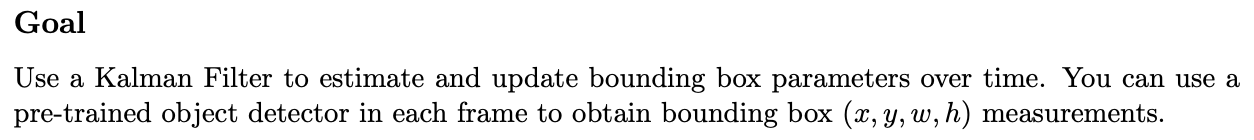
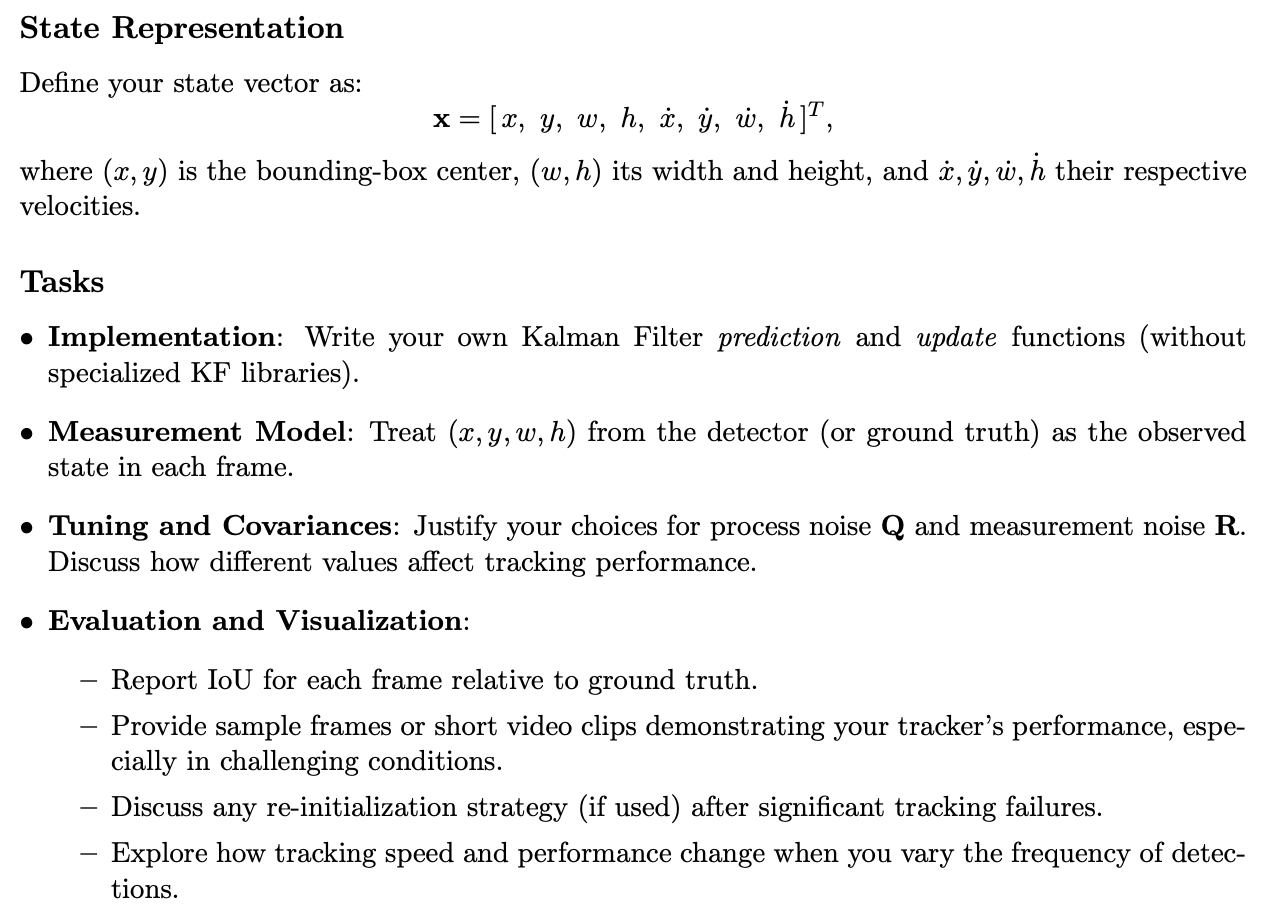

In [4]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [5]:
""" --- Helper Functions ------------------------------- """

def calculate_iou(pred_box, gt_box):
    
    x_left = max(pred_box[0], gt_box[0])
    y_top = max(pred_box[1], gt_box[1])
    x_right = min(pred_box[2], gt_box[2])
    y_bottom = min(pred_box[3], gt_box[3])
    
    if x_right < x_left or y_bottom < y_top:
        return 0.0
    
    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    pred_box_area = (pred_box[2] - pred_box[0]) * (pred_box[3] - pred_box[1])
    gt_box_area = (gt_box[2] - gt_box[0]) * (gt_box[3] - gt_box[1])
    
    return intersection_area / (pred_box_area + gt_box_area - intersection_area)


def convert_points_to_bbox(points):
    points = np.array(points).reshape(4, 2)
    x_min, y_min = np.min(points, axis=0)
    x_max, y_max = np.max(points, axis=0)
    return [x_min, y_min, x_max, y_max]


In [6]:
sequence_path = "dataset/vot18st/sequences/butterfly"
gt_file = os.path.join(sequence_path, 'groundtruth.txt')

""" --- Data Loading ------------------------------- """

# Read ground truth data
with open(gt_file, 'r') as f:
    ground_truths = []
    for line in f:
        values = list(map(float, line.strip().split(',')))
        ground_truths.append(values)

# Load sequence
images = [cv2.imread(f"{sequence_path}/color/{i:08d}.jpg") for i in range(1, len(ground_truths) + 1)]

In [7]:
""" --- KF Class: Using cv2.KalmanFilter ------------------------------- """

class KalmanFilter:
    def __init__(self, dt=1.0):
        # State dimension: [x, y, w, h, x_v, y_v, w_v, h_v]
        self.kf = cv2.KalmanFilter(8, 4, 0)  # 8 states, 4 measurements
        
        # Transition matrix
        self.kf.transitionMatrix = np.array([
            [1, 0, 0, 0, dt, 0, 0, 0],
            [0, 1, 0, 0, 0, dt, 0, 0],
            [0, 0, 1, 0, 0, 0, dt, 0],
            [0, 0, 0, 1, 0, 0, 0, dt],
            [0, 0, 0, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 0, 0, 1]
        ], dtype=np.float32)

        # Measurement matrix
        self.kf.measurementMatrix = np.array([
            [1, 0, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 1, 0, 0, 0, 0]
        ], dtype=np.float32)

        # Covariance matrices
        self.kf.processNoiseCov = 1e-4 * np.eye(8, dtype=np.float32)
        self.kf.measurementNoiseCov = 1e-3 * np.eye(4, dtype=np.float32)
        self.kf.errorCovPost = 1e-1 * np.eye(8, dtype=np.float32)

    def predict(self):
        return self.kf.predict()

    def correct(self, measurement):
        return self.kf.correct(measurement)

In [8]:
""" --- KF Class: Non-CV2 ------------------------------- """

class KalmanFilter:
    def __init__(self, dt=1.0):
        
        self.x_prior = None
        self.P_prior = None
        
        # Transition matrix
        self.F = np.array([
            [1, 0, 0, 0, dt, 0, 0, 0],
            [0, 1, 0, 0, 0, dt, 0, 0],
            [0, 0, 1, 0, 0, 0, dt, 0],
            [0, 0, 0, 1, 0, 0, 0, dt],
            [0, 0, 0, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 0, 0, 1]
        ], dtype=np.float32)
        
        # Measurement matrix
        self.H = np.array([
            [1, 0, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 1, 0, 0, 0, 0]
        ], dtype=np.float32)
        
        # Covariance matrices
        self.Q = 1e-4 * np.eye(8, dtype=np.float32)
        self.R = 1e-3 * np.eye(4, dtype=np.float32)
        self.x_post = np.zeros((8, 1), dtype=np.float32)
        self.P_post = 1e-1 * np.eye(8, dtype=np.float32)

    def predict(self):
        self.x_prior = self.F @ self.x_post
        self.P_prior = self.F @ self.P_post @ self.F.T + self.Q
        return self.x_prior

    def correct(self, measurement):
        z = np.array(measurement, dtype=np.float32).reshape(4, 1)
        y = z - self.H @ self.x_prior
        S = self.H @ self.P_prior @ self.H.T + self.R
        K = self.P_prior @ self.H.T @ np.linalg.inv(S)
        self.x_post = self.x_prior + K @ y
        self.P_post = (np.eye(8) - K @ self.H) @ self.P_prior
        return self.x_post

In [9]:
""" --- Model Initialization ------------------------------- """

# Initialize first bbox as the ground truth bbox with no velocities
initial_gt = ground_truths[0]
points = np.array(initial_gt, dtype=np.float32).reshape(4, 2)
rect = cv2.minAreaRect(points)
(x, y), (w, h), _ = rect

iou_values = []

kf = KalmanFilter(dt=1.0)
# kf.kf.statePost = np.array([[x], [y], [w], [h], [0.0], [0.0], [0.0], [0.0]], dtype=np.float32)

initial_state = np.array([[x], [y], [w], [h], [0.0], [0.0], [0.0], [0.0]], dtype=np.float32)
kf.x_post = initial_state
kf.P_post = 1e-1 * np.eye(8, dtype=np.float32)

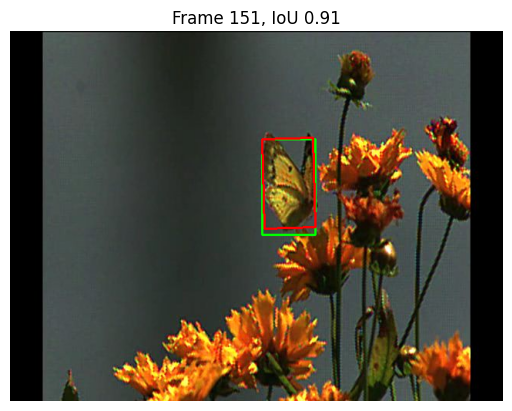

In [10]:
""" --- Tracking ------------------------------- """

for i, img in enumerate(images):
    prediction = kf.predict()
    
    # Predictions ------------------------------
    x_pred = prediction[0, 0]
    y_pred = prediction[1, 0]
    w_pred = prediction[2, 0]
    h_pred = prediction[3, 0]
    
    # Draw Prediction bbox --------------------
    x1_pred = int(x_pred - w_pred/2)
    y1_pred = int(y_pred - h_pred/2)
    x2_pred = int(x_pred + w_pred/2)
    y2_pred = int(y_pred + h_pred/2)
    cv2.rectangle(img, (x1_pred, y1_pred), (x2_pred, y2_pred), (0, 255, 0), 2)

    # Ground Truth ----------------------------
    current_gt = ground_truths[i]
    points = np.array(current_gt, dtype=np.float32).reshape(4, 2)
    gt_points = points.reshape(-1, 2)
    x_min, y_min = np.min(gt_points, axis=0)
    x_max, y_max = np.max(gt_points, axis=0)
    gt_box = (x_min, y_min, x_max, y_max)
    
    # Draw Ground Truth bbox ------------------
    gt_poly = points.reshape((-1, 1, 2)).astype(np.int32)
    cv2.polylines(img, [gt_poly], isClosed=True, color=(0,0,255), thickness=2)
    
    # Calculate IoU ----------------------------
    pred_box = (x1_pred, y1_pred, x2_pred, y2_pred)
    iou = calculate_iou(gt_box, pred_box)
    iou_values.append(iou)

    # Apply measurement matrix -----------------
    rect = cv2.minAreaRect(points)
    (x_meas, y_meas), (w_meas, h_meas), _ = rect
    measurement = np.array([[x_meas], [y_meas], [w_meas], [h_meas]], dtype=np.float32)
    kf.correct(measurement)

    """ --- Optional: Plotting ------------------------------- """
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f'Frame {i+1}, IoU {iou:.2f}')
    display(plt.gcf())
    clear_output(wait=True)
    plt.pause(0.001)

## Deep-Learning Based Tracking

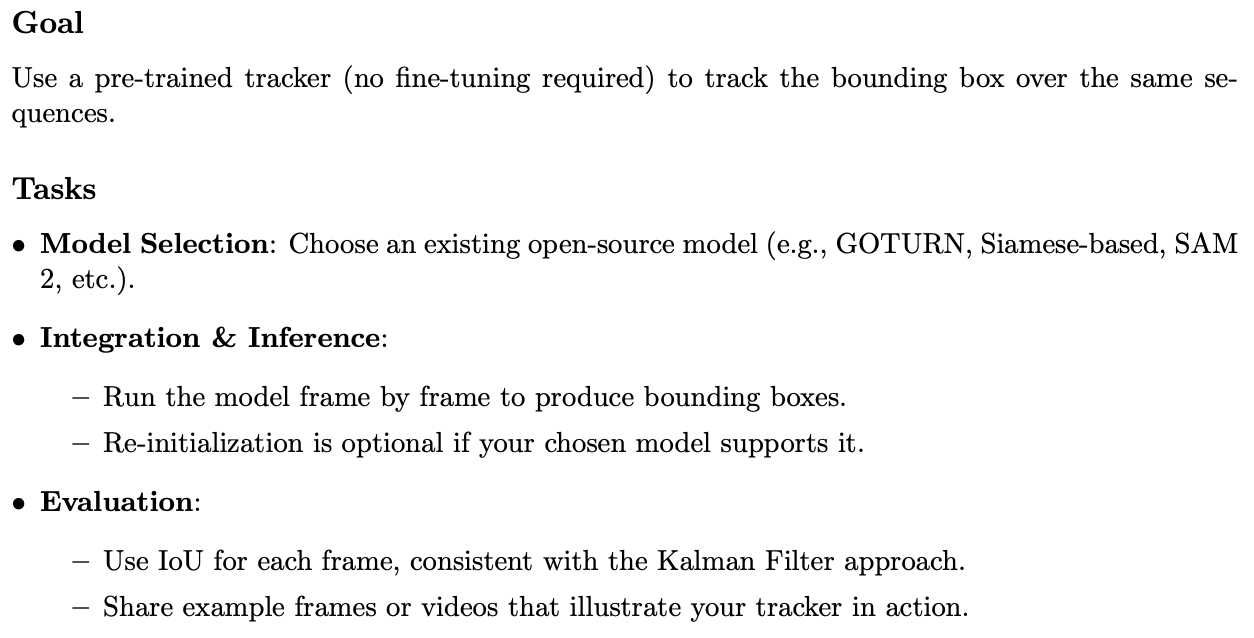

In [11]:
import torch
from ultralytics import YOLO
from ultralytics.engine.results import Results

model = YOLO('yolov8n.pt')  # yolov8n, yolov8x

In [12]:
""" --- Model Initialization ------------------------------- """

# Initialize first bbox as the ground truth bbox
initial_bbox = convert_points_to_bbox(ground_truths[0])
x1, y1, x2, y2 = map(int, initial_bbox)

boxes = torch.tensor([[x1, y1, x2, y2, 0.9, 0]])

results = Results(orig_img=images[0], path="", names=model.names, boxes=boxes)
model.track(images[0], persist=True, iou=0.3, conf=0.1, tracker="botsort.yaml", verbose=False, classes=None)

iou_values = []
track_id = None

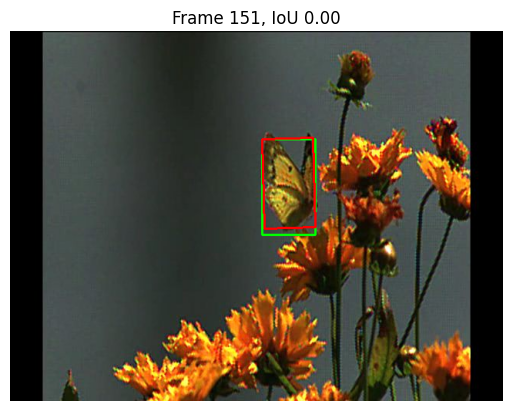

In [13]:
""" --- Tracking ------------------------------- """
# Note: I changed something and the tracker started working... -.-'...

for i, (frame, gt_points) in enumerate(zip(images, ground_truths)):
    if i == 0:
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        pred_bbox = None
    else:
        results = model.track(frame, persist=True, iou=0.3, tracker="botsort.yaml", verbose=False)
        gt_bbox = convert_points_to_bbox(gt_points)
        pred_bbox = None

        # Fallback: If the detection is lost, fall back to the largest bbox
        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            ids = results[0].boxes.id.cpu().numpy().astype(int)
            largest_area = 0

            for box, tid in zip(boxes, ids):
                area = (box[2]-box[0])*(box[3]-box[1])
                if area > largest_area:
                    pred_bbox = box
                    track_id = tid
                    largest_area = area

        # Calculate IoU
        iou = calculate_iou(pred_bbox, gt_bbox) if pred_bbox is not None else 0.0
        iou_values.append(iou)
    
    """ --- Optional: Plotting ------------------------------- """

    # Draw Predicted bbox ------------------------------------
    if pred_bbox is not None:
        x1, y1, x2, y2 = map(int, pred_bbox)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Draw Ground Truth bbox ---------------------------------
    gt_points = np.array(gt_points).reshape(4, 2).astype(int)
    cv2.polylines(frame, [gt_points], True, (0, 0, 255), 2)

    # Plot ---------------------------------------------------
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f'Frame {i+1}, IoU {iou:.2f}')
    display(plt.gcf())
    clear_output(wait=True)
    plt.pause(0.001)

## Observations

Median IoU: 	 0.0
Mean IoU: 	 0.23


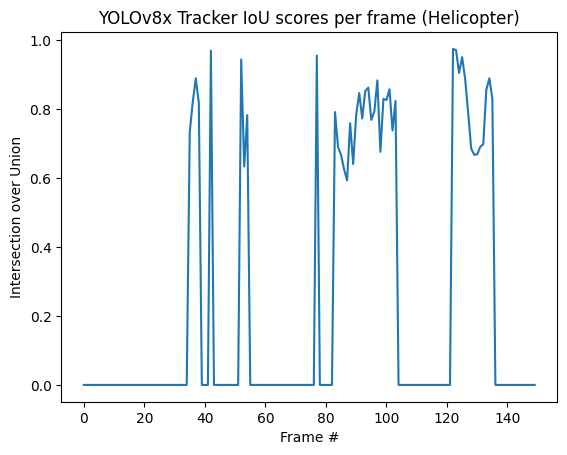

In [14]:
"""Manually change parameters in the above cells and then run this cell to collect data"""

MODEL = "YOLOv8x"
SEQUENCE = "Helicopter"

plt.plot(iou_values)
plt.title(f'{MODEL} Tracker IoU scores per frame ({SEQUENCE})')
plt.xlabel('Frame #')
plt.ylabel('Intersection over Union')

print(f"Median IoU: \t {round(np.median(iou_values), 2)}")
print(f"Mean IoU: \t {round(np.mean(iou_values), 2)}")

### Aggregating Results

In [15]:
"""Present the results in a Pandas DataFrame"""

import pandas as pd

data = [{'Model': 'Kalman',
         'Sequence': 'Butterfly',
         'Mean IoU': 0.52,
         'Median IoU': 0.49,
         'Runtime (s)': 0.1,
         'FPS': 1510},
        {'Model': 'Kalman',
         'Sequence': 'Helicopter',
         'Mean IoU': 0.62,
         'Median IoU': 0.63,
         'Runtime (s)': 0.5,
         'FPS': 1416},
        {'Model': 'VOLOv8s',
         'Sequence': 'Butterfly',
         'Mean IoU': 0.08,
         'Median IoU': 0.0,
         'Runtime (s)': 5.7,
         'FPS': 26},
        {'Model': 'VOLOv8s',
         'Sequence': 'Helicopter',
         'Mean IoU': 0.09,
         'Median IoU': 0.09,
         'Runtime (s)': 21.5,
         'FPS': 32},
        {'Model': 'VOLOv8x',
         'Sequence': 'Butterfly',
         'Mean IoU': 0.04,
         'Median IoU': 0.04,
         'Runtime (s)': 47.1,
         'FPS': 3},
        {'Model': 'VOLOv8x',
         'Sequence': 'Helicopter',
         'Mean IoU': 0.09,
         'Median IoU': 0.1,
         'Runtime (s)': 177.5,
         'FPS': 4}]

df = pd.DataFrame(data).sort_values(by=['Model', 'Sequence'])
df.style.hide(axis='index').format(precision=2)

Model,Sequence,Mean IoU,Median IoU,Runtime (s),FPS
Kalman,Butterfly,0.52,0.49,0.10,1510
Kalman,Helicopter,0.62,0.63,0.50,1416
VOLOv8s,Butterfly,0.08,0.00,5.70,26
VOLOv8s,Helicopter,0.09,0.09,21.50,32
VOLOv8x,Butterfly,0.04,0.04,47.10,3
VOLOv8x,Helicopter,0.09,0.10,177.50,4
